<a href="https://colab.research.google.com/github/Biilzaa/TugasPraktikum1---AI/blob/main/PraktikumMandiriRegresiBerganda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Tahap 1: Inisialisasi Library

Persiapan modul untuk pemodelan multivariat dan pengukuran kinerja regresi.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

Tahap 2: Penyusunan Dataset Multivariat

Dataset mencakup variabel harga mobil bekas yang dipengaruhi oleh usia kendaraan, jarak tempuh, dan kapasitas mesin.

In [2]:
data = {
    'usia_mobil': [1, 3, 5, 2, 4, 6, 7, 3, 8, 5],
    'jarak_tempuh': [15, 45, 80, 30, 60, 95, 110, 40, 130, 75],
    'mesin_cc': [1500, 1200, 1500, 2000, 1200, 1000, 1500, 2000, 1000, 1200],
    'harga': [250, 190, 160, 280, 175, 120, 140, 260, 100, 155]
}

df = pd.DataFrame(data)
print(df)

   usia_mobil  jarak_tempuh  mesin_cc  harga
0           1            15      1500    250
1           3            45      1200    190
2           5            80      1500    160
3           2            30      2000    280
4           4            60      1200    175
5           6            95      1000    120
6           7           110      1500    140
7           3            40      2000    260
8           8           130      1000    100
9           5            75      1200    155


Tahap 3: Spesifikasi Fitur Multivariat dan TargetDidefinisikan variabel prediktor majemuk ($x_1, x_2, x_3$) untuk memprediksi variabel target tunggal (y).

In [3]:
# menentukan variabel
X = df[['usia_mobil', 'jarak_tempuh', 'mesin_cc']]
y = df['harga']

Tahap 4: Pembagian Data Training dan Testing

Partisi dataset dilakukan untuk menjaga integritas pengujian model.

In [4]:
# split data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Tahap 5: Pengembangan Model Regresi Linear Berganda

Algoritma dilatih untuk memetakan hubungan linear antara beberapa variabel prediktor terhadap variabel target.

In [5]:
# membuat model regresi
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Tahap 6: Analisis Koefisien Regresi Majemuk

Pemeriksaan nilai Intercept dan Koefisien untuk setiap fitur guna mengidentifikasi besarnya pengaruh masing-masing prediktor terhadap harga.

In [6]:
# melihat atau menghitung koefisien
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)
# b1 → pengaruh usia mobil
# b2 → pengaruh jarak tempuh
# b3 → pengaruh mesin_cc

Intercept (a): 151.6905444126078
Koefisien (b1, b2, b3): [ 6.54727794 -1.62464183  0.0782235 ]


Tahap 7: Validasi Prediksi pada Data Testing

Dilakukan komparasi antara hasil estimasi model dengan data aktual untuk meninjau akurasi prediksi.

In [7]:
# prediksi data testing
y_pred = model.predict(X_test)

print("Prediksi:", y_pred)
print("Nilai Asli:", y_test.values)

Prediksi: [ 71.08882521 192.09169054]
Nilai Asli: [100 190]


Tahap 8: Visualisasi Komparatif Nilai Aktual vs Estimasi

Visualisasi sebaran data antara nilai asli dan hasil prediksi digunakan untuk meninjau korelasi dan tingkat presisi model.

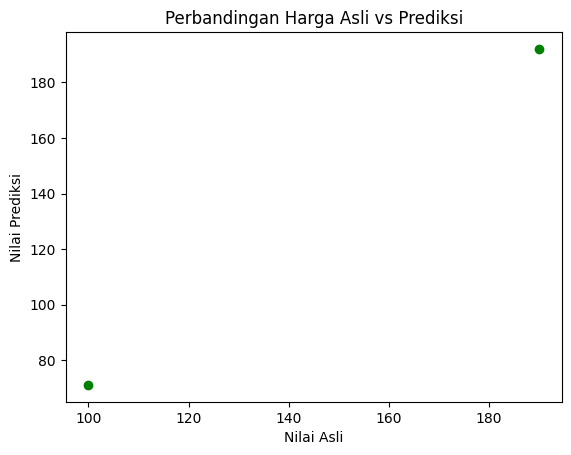

In [8]:
# tampil visualisasi
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred, color='green')
plt.xlabel("Nilai Asli")
plt.ylabel("Nilai Prediksi")
plt.title("Perbandingan Harga Asli vs Prediksi")
plt.show()

Tahap 9: Analisis Metrik Evaluasi

Pengukuran akurasi model menggunakan parameter MAE, MSE, dan RMSE.

In [9]:
# evaluasi model
import numpy as np
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 15.5014326647565
MSE: 420.11559839410324
RMSE: 20.49672164991522


Tahap 10: Eksekusi Prediksi pada Observasi Baru

Mengaplikasikan model pada sampel data baru untuk mendapatkan taksiran harga secara otomatis.

In [10]:
data_baru = pd.DataFrame([[4, 50, 1500]], columns=['usia_mobil', 'jarak_tempuh', 'mesin_cc'])
prediksi = model.predict(data_baru)

print("Prediksi harga mobil:", prediksi[0])

Prediksi harga mobil: 213.98280802292254
